In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d swaroopkml/cifar10-pngs-in-folders
!unzip cifar10-pngs-in-folders.zip

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

In [16]:
train_transform = transforms.Compose([
  transforms.Resize(224),
  transforms.RandomCrop(224, padding=28),
  transforms.RandomHorizontalFlip(),
  transforms.ToTensor(),
  transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
  transforms.Resize(224),
  transforms.ToTensor(),
  transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

In [17]:
full_train_dataset = ImageFolder(root="/content/cifar10/cifar10/train",transform=None)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset,[train_size, val_size])
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset = ImageFolder(root="/content/cifar10/cifar10/test",transform=test_transform)

In [11]:
print("Train samples ::", len(train_dataset))
print("Validation samples ::", len(val_dataset))
print("Test samples ::", len(test_dataset))
print("------------------------------------")
classes = train_dataset.dataset.classes
print("Number of classes ::", len(classes))
print("Classes list ::")

for i, cls in enumerate(classes):
  print(f"{i} :։ class {cls}")

img, label = train_dataset[0]
print("Image shape ::", img.shape)


Train samples :: 40000
Validation samples :: 10000
Test samples :: 10000
------------------------------------
Number of classes :: 10
Classes list ::
0 :։ class airplane
1 :։ class automobile
2 :։ class bird
3 :։ class cat
4 :։ class deer
5 :։ class dog
6 :։ class frog
7 :։ class horse
8 :։ class ship
9 :։ class truck
Image shape :: torch.Size([3, 32, 32])


In [18]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [19]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [20]:
for param in model.parameters():
  param.requires_grad = True

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=10,gamma=0.1)

In [22]:
num_epochs = 20
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100 * correct / total)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100 * correct / total)

    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), "best_model.pth")
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_losses[-1]} | Val Loss: {val_losses[-1]} | Train Acc: {train_accs[-1]}% | Val Acc: {val_accs[-1]}%")

Epoch 1/20 | Train Loss: 0.428089037322998 | Val Loss: 0.2637588383190951 | Train Acc: 85.2775% | Val Acc: 90.93%
Epoch 2/20 | Train Loss: 0.16676696199178695 | Val Loss: 0.2371997511738045 | Train Acc: 94.2025% | Val Acc: 92.13%
Epoch 3/20 | Train Loss: 0.0910962176784873 | Val Loss: 0.27066331499131624 | Train Acc: 96.8775% | Val Acc: 91.91%
Epoch 4/20 | Train Loss: 0.061291564117372035 | Val Loss: 0.2822952886960309 | Train Acc: 97.9275% | Val Acc: 91.95%
Epoch 5/20 | Train Loss: 0.04369646391421556 | Val Loss: 0.2698865451725425 | Train Acc: 98.5425% | Val Acc: 92.37%
Epoch 6/20 | Train Loss: 0.036641481906548146 | Val Loss: 0.26498556433684506 | Train Acc: 98.7675% | Val Acc: 92.59%
Epoch 7/20 | Train Loss: 0.026758174752630294 | Val Loss: 0.25618191215263053 | Train Acc: 99.135% | Val Acc: 92.87%
Epoch 8/20 | Train Loss: 0.02048651350894943 | Val Loss: 0.24849542166302158 | Train Acc: 99.3475% | Val Acc: 93.45%
Epoch 9/20 | Train Loss: 0.01141847009519115 | Val Loss: 0.2386628412

In [23]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

test_acc = 100 * correct / total
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 95.24


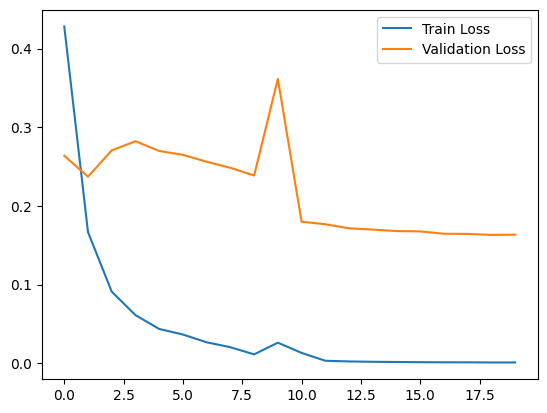

In [24]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()

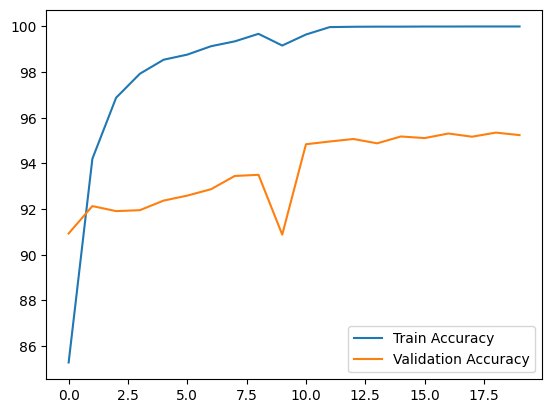

In [26]:
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.show()

In [29]:
all_preds = []
all_labels = []
model.eval()

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1000
           1       0.97      0.98      0.97      1000
           2       0.96      0.93      0.95      1000
           3       0.89      0.88      0.89      1000
           4       0.96      0.97      0.96      1000
           5       0.92      0.92      0.92      1000
           6       0.96      0.98      0.97      1000
           7       0.97      0.96      0.97      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.96      0.97      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



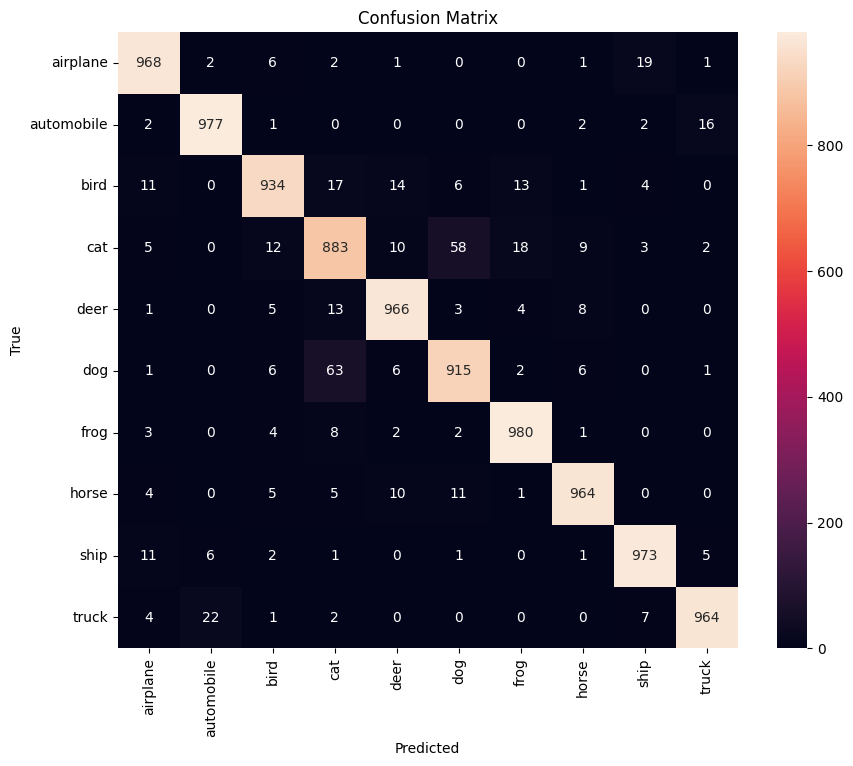

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
cm = confusion_matrix(all_labels, all_preds)
classes = train_dataset.dataset.classes
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',xticklabels=classes,yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [30]:
torch.save(model.state_dict(), "resnet18_cifar10.pth")

In [31]:
model.load_state_dict(torch.load("resnet18_cifar10.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  